# Mammographic Mass — ML Classifier

## Business Question
> **Can we develop a machine learning model to assist radiologists in distinguishing malignant from benign breast masses using mammographic features, in order to reduce unnecessary biopsies while maintaining high cancer detection rates?**

## Dataset
The [Mammographic Mass dataset](https://archive.ics.uci.edu/dataset/161/mammographic+mass) contains 961 samples from the Institute of Radiology, University Erlangen-Nuremberg (2003–2006). Unlike the clean Wisconsin dataset, this data includes **missing values**, **ordinal categorical features**, and reflects the kind of real-world clinical data messiness you'd encounter in practice.

| Feature | Type | Description |
|---|---|---|
| BI-RADS | Ordinal (1–5) | Radiologist assessment score |
| Age | Integer | Patient age in years |
| Shape | Ordinal (1–4) | round=1, oval=2, lobular=3, irregular=4 |
| Margin | Ordinal (1–5) | circumscribed=1, microlobulated=2, obscured=3, ill-defined=4, spiculated=5 |
| Density | Ordinal (1–4) | high=1, iso=2, low=3, fat-containing=4 |
| **Severity** | Binary (target) | benign=0, malignant=1 |

## Notebook Structure
1. Exploratory Data Analysis (EDA)
2. Preprocessing — Imputation, Feature Selection, Scaling
3. Baseline Model — Logistic Regression
4. Advanced Models — Random Forest & SVM
5. Evaluation — AUC-ROC, Confusion Matrix, Threshold Tuning

---
## 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

MALIGNANT_COLOR = '#e74c3c'
BENIGN_COLOR    = '#2ecc71'

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 Load and Inspect the Raw Data

In [2]:
dataset = fetch_ucirepo(id=161)
X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

mammo = X_raw.copy()
mammo['Severity'] = y_raw.values.ravel()
mammo['diagnosis'] = mammo['Severity'].map({0: 'Benign', 1: 'Malignant'})

print(f'Dataset shape: {mammo.shape}')
print(f'Column names: {mammo.columns.tolist()}')
mammo.info()

Dataset shape: (961, 7)
Column names: ['BI-RADS', 'Age', 'Shape', 'Margin', 'Density', 'Severity', 'diagnosis']
<class 'pandas.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   BI-RADS    959 non-null    float64
 1   Age        956 non-null    float64
 2   Shape      930 non-null    float64
 3   Margin     913 non-null    float64
 4   Density    885 non-null    float64
 5   Severity   961 non-null    int64  
 6   diagnosis  961 non-null    str    
dtypes: float64(5), int64(1), str(1)
memory usage: 52.7 KB


In [3]:
mammo.describe().round(2)

,BI-RADS,Age,Shape,Margin,Density,Severity
count,959.00,956.00,930.00,913.00,885.00,961.00
mean,4.35,55.49,2.72,2.80,2.91,0.46
std,1.78,14.48,1.24,1.57,0.38,0.50
min,0.00,18.00,1.00,1.00,1.00,0.00
25%,4.00,45.00,2.00,1.00,3.00,0.00
50%,4.00,57.00,3.00,3.00,3.00,0.00
75%,5.00,66.00,4.00,4.00,3.00,1.00
max,55.00,96.00,4.00,5.00,4.00,1.00


### 1.2 Data Cleaning

This dataset has **real missing values** — a key difference from the Wisconsin dataset. We need to understand the pattern before deciding on an imputation strategy.

=== Missing Values ===
         Missing Count  Missing %
BI-RADS              2        0.2
Age                  5        0.5
Shape               31        3.2
Margin              48        5.0
Density             76        7.9


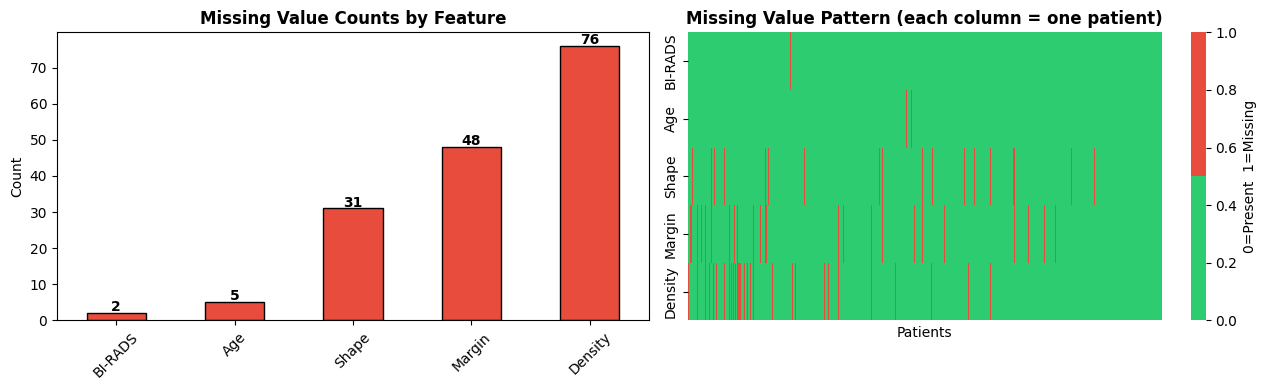


Duplicate rows: 272
Removed. New shape: (689, 7)


In [4]:
missing = mammo.isnull().sum()
missing_pct = (mammo.isnull().sum() / len(mammo) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== Missing Values ===')
print(missing_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

missing_df['Missing Count'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Missing Value Counts by Feature', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(missing_df['Missing Count']):
    axes[0].text(i, v + 0.5, f'{v}', ha='center', fontweight='bold')

feature_cols = ['BI-RADS', 'Age', 'Shape', 'Margin', 'Density']
miss_matrix = mammo[feature_cols].isnull().astype(int)
sns.heatmap(miss_matrix.T, cmap=['#2ecc71', '#e74c3c'], ax=axes[1],
            cbar_kws={'label': '0=Present  1=Missing'},
            xticklabels=False, yticklabels=True)
axes[1].set_title('Missing Value Pattern (each column = one patient)', fontweight='bold')
axes[1].set_xlabel('Patients')

plt.tight_layout()
plt.show()

dupes = mammo.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
if dupes > 0:
    mammo = mammo.drop_duplicates()
    print(f'Removed. New shape: {mammo.shape}')

**Observation:** `density` has the most missing values (76, ~7.9%), followed by `margin` (48, ~5%). Missingness appears spread across patients rather than clustered, suggesting **Missing At Random (MAR)** — median imputation is appropriate for these ordinal features.

### 1.3 BI-RADS: Data Leakage Discussion

BI-RADS is the radiologist's own assessment score — essentially a pre-diagnosis. Including it would cause **data leakage**: the model would be learning from the answer, not the raw features. We will drop it for modeling.

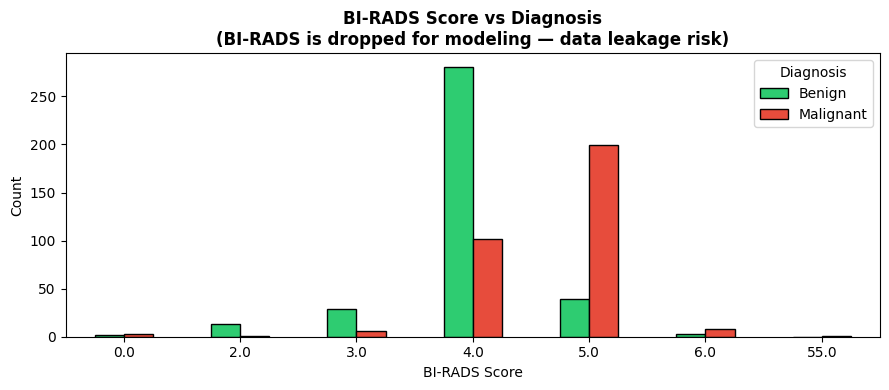

BI-RADS is strongly associated with diagnosis — using it would leak the label into features.
It will be excluded from all models.


In [5]:
# Show BI-RADS vs Severity relationship to illustrate the leakage concern
birads_counts = mammo.groupby(['BI-RADS', 'diagnosis']).size().unstack(fill_value=0)

birads_counts.plot(kind='bar', figsize=(9, 4),
                  color=[BENIGN_COLOR, MALIGNANT_COLOR], edgecolor='black')
plt.title('BI-RADS Score vs Diagnosis\n(BI-RADS is dropped for modeling — data leakage risk)',
          fontweight='bold')
plt.xlabel('BI-RADS Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

print('BI-RADS is strongly associated with diagnosis — using it would leak the label into features.')
print('It will be excluded from all models.')

### 1.4 Class Distribution

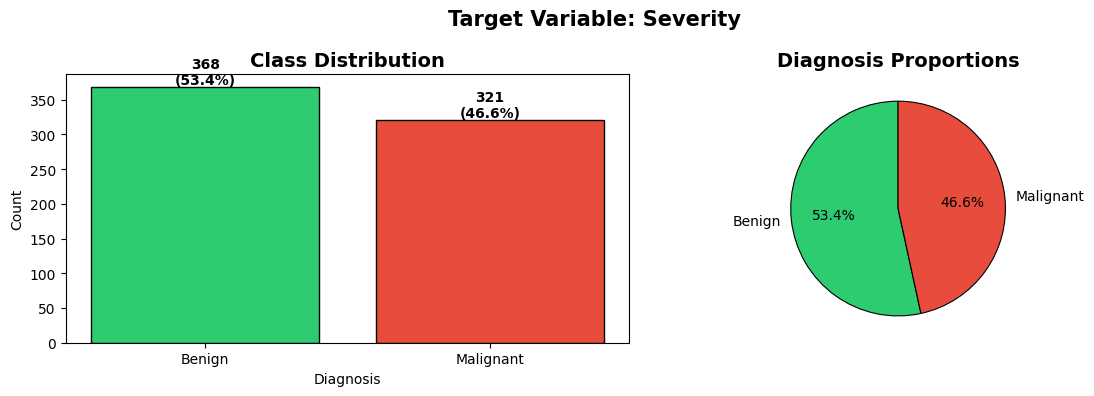

           Count  Percentage (%)
diagnosis                       
Benign       368            53.4
Malignant    321            46.6


In [6]:
class_counts = mammo['diagnosis'].value_counts()
class_pcts   = mammo['diagnosis'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [BENIGN_COLOR, MALIGNANT_COLOR]
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, (val, pct) in enumerate(zip(class_counts.values, class_pcts.values)):
    axes[0].text(i, val + 4, f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(
    class_counts.values, labels=class_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[1].set_title('Diagnosis Proportions', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Severity', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pcts.round(1)}))

**Observation:** The class distribution is fairly balanced (~54% benign, ~46% malignant) — better than the Wisconsin dataset. Stratified splitting is still used as good practice.

### 1.5 Feature Distributions by Diagnosis

Since all features are **ordinal integers**, we use count plots rather than histograms.

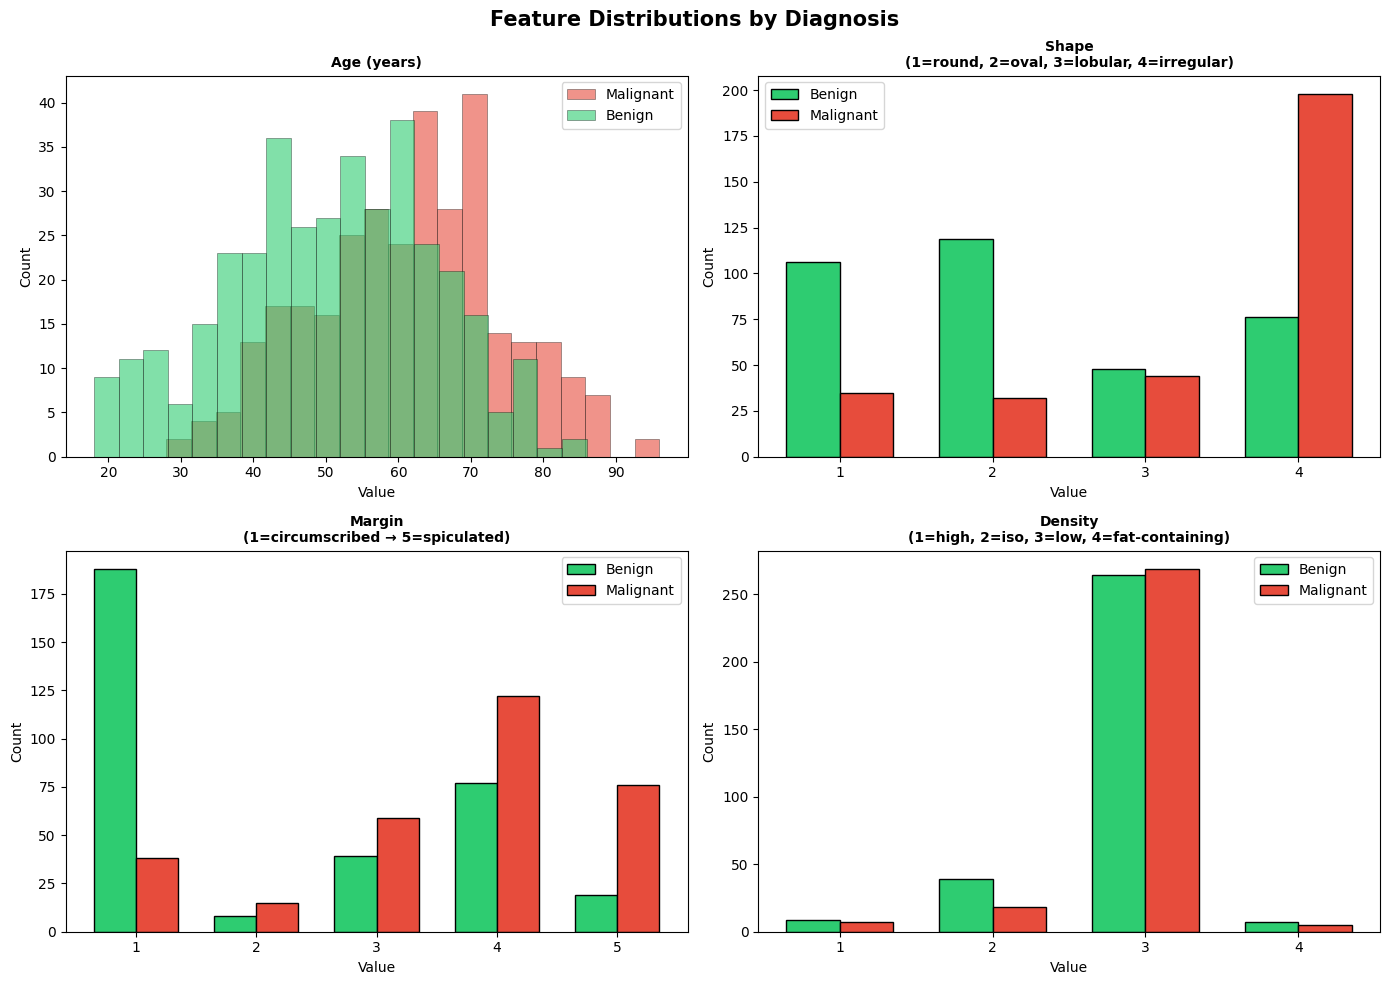

In [7]:
model_features = ['Age', 'Shape', 'Margin', 'Density']
feature_labels = {
    'Age':     'Age (years)',
    'Shape':   'Shape\n(1=round, 2=oval, 3=lobular, 4=irregular)',
    'Margin':  'Margin\n(1=circumscribed → 5=spiculated)',
    'Density': 'Density\n(1=high, 2=iso, 3=low, 4=fat-containing)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(model_features):
    if feature == 'Age':
        for diagnosis, color in [('Malignant', MALIGNANT_COLOR), ('Benign', BENIGN_COLOR)]:
            subset = mammo[mammo['diagnosis'] == diagnosis][feature].dropna()
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                         label=diagnosis, edgecolor='black', linewidth=0.4)
        axes[i].set_ylabel('Count')
        axes[i].legend()
    else:
        plot_data = mammo[['diagnosis', feature]].dropna()
        benign_counts    = plot_data[plot_data['diagnosis'] == 'Benign'][feature].value_counts().sort_index()
        malignant_counts = plot_data[plot_data['diagnosis'] == 'Malignant'][feature].value_counts().sort_index()
        all_vals = sorted(plot_data[feature].unique())
        x = np.arange(len(all_vals))
        width = 0.35
        axes[i].bar(x - width/2,
                    [benign_counts.get(v, 0) for v in all_vals],
                    width, label='Benign', color=BENIGN_COLOR, edgecolor='black')
        axes[i].bar(x + width/2,
                    [malignant_counts.get(v, 0) for v in all_vals],
                    width, label='Malignant', color=MALIGNANT_COLOR, edgecolor='black')
        axes[i].set_xticks(x)
        axes[i].set_xticklabels([int(v) for v in all_vals])
        axes[i].set_ylabel('Count')
        axes[i].legend()

    axes[i].set_title(feature_labels[feature], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')

plt.suptitle('Feature Distributions by Diagnosis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Box Plots by Diagnosis

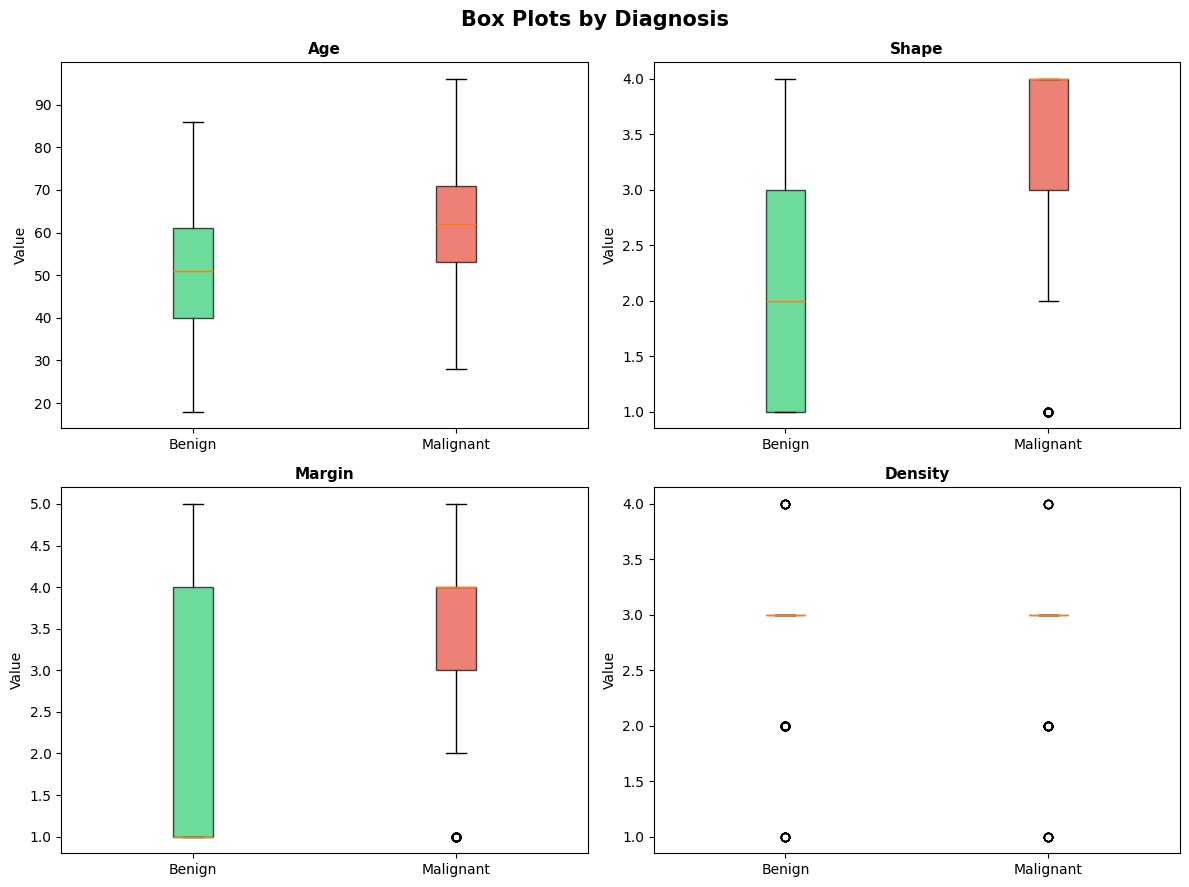

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(model_features):
    benign    = mammo[mammo['diagnosis'] == 'Benign'][feature].dropna()
    malignant = mammo[mammo['diagnosis'] == 'Malignant'][feature].dropna()

    bp = axes[i].boxplot(
        [benign, malignant], labels=['Benign', 'Malignant'],
        patch_artist=True
    )
    bp['boxes'][0].set_facecolor(BENIGN_COLOR);    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(MALIGNANT_COLOR); bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(feature.title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots by Diagnosis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.7 Correlation Heatmap

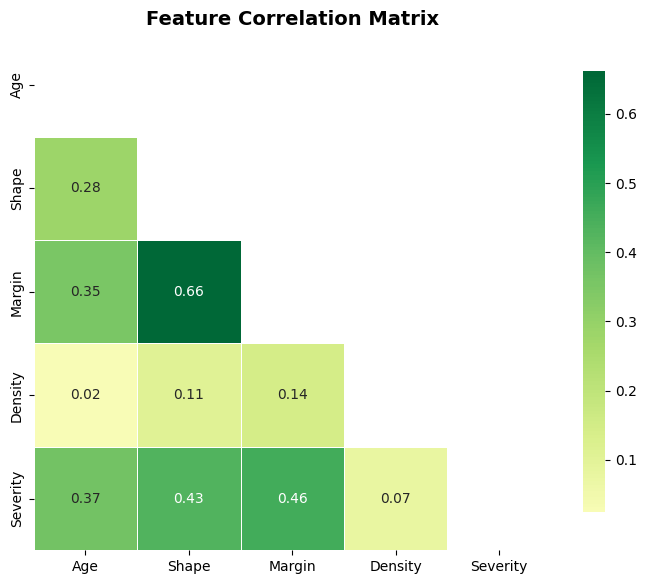

In [9]:
corr_cols = model_features + ['Severity']
corr_matrix = mammo[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Preprocessing

Steps:
1. **Drop BI-RADS** — data leakage risk (radiologist assessment, not raw measurement)
2. **Impute missing values** — median strategy (appropriate for ordinal features)
3. **Standardize features** — required for Logistic Regression and SVM
4. **Stratified 80/20 train-test split**

In [10]:
X = mammo[model_features].copy()
y = mammo['Severity'].copy()
y_label = mammo['diagnosis'].copy()

print('Missing values BEFORE imputation:')
print(X.isnull().sum())

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print('\nMissing values AFTER imputation:')
print(X_imputed.isnull().sum())
print(f'\nImputed medians: {dict(zip(X.columns, imputer.statistics_.round(1)))}')

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
_, _, y_train_label, y_test_label = train_test_split(
    X_scaled, y_label, test_size=0.2, stratify=y_label, random_state=42
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining class distribution:')
print(pd.Series(y_train).value_counts().rename({1: 'Malignant', 0: 'Benign'}))
print(f'\nTest class distribution:')
print(pd.Series(y_test).value_counts().rename({1: 'Malignant', 0: 'Benign'}))

Missing values BEFORE imputation:
Age         4
Shape      31
Margin     48
Density    71
dtype: int64

Missing values AFTER imputation:
Age        0
Shape      0
Margin     0
Density    0
dtype: int64

Imputed medians: {'Age': np.float64(57.0), 'Shape': np.float64(3.0), 'Margin': np.float64(3.0), 'Density': np.float64(3.0)}

Training set: 551 samples
Test set:     138 samples

Training class distribution:
Severity
Benign       294
Malignant    257
Name: count, dtype: int64

Test class distribution:
Severity
Benign       74
Malignant    64
Name: count, dtype: int64


---
## 3. Baseline Model — Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_lr):.4f}  <- cancer detection rate')
print(f'Specificity:            {tn / (tn + fp):.4f}  <- benign correctly identified')
print(f'Precision:              {precision_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')
print(f'\nConfusion Matrix:')
print(pd.crosstab(
    y_test_label,
    pd.Categorical(np.where(y_pred_lr == 1, 'Malignant', 'Benign'),
                   categories=['Benign', 'Malignant']),
    rownames=['Actual'], colnames=['Predicted']
))

=== Logistic Regression (Baseline) ===
Accuracy:               0.7536
Sensitivity (Recall):   0.8438  <- cancer detection rate
Specificity:            0.6757  <- benign correctly identified
Precision:              0.6923
AUC-ROC:                0.8268
False Negatives (missed cancers):    10
False Positives (unnecessary biops): 24

Confusion Matrix:
Predicted  Benign  Malignant
Actual                      
Benign         50         24
Malignant      10         54


---
## 4. Advanced Models

### 4.1 Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print('=== Random Forest (Default) ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_rf):.4f}')
print(f'Specificity:            {tn / (tn + fp):.4f}')
print(f'Precision:              {precision_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')
print(f'\nConfusion Matrix:')
print(pd.crosstab(
    y_test_label,
    pd.Categorical(np.where(y_pred_rf == 1, 'Malignant', 'Benign'),
                   categories=['Benign', 'Malignant']),
    rownames=['Actual'], colnames=['Predicted']
))

=== Random Forest (Default) ===
Accuracy:               0.6304
Sensitivity (Recall):   0.6719
Specificity:            0.5946
Precision:              0.5890
AUC-ROC:                0.6830
False Negatives (missed cancers):    21
False Positives (unnecessary biops): 30

Confusion Matrix:
Predicted  Benign  Malignant
Actual                      
Benign         44         30
Malignant      21         43


### 4.2 Support Vector Machine (SVM)

In [13]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()

print('=== Support Vector Machine ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_svm):.4f}')
print(f'Specificity:            {tn / (tn + fp):.4f}')
print(f'Precision:              {precision_score(y_test, y_pred_svm):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_svm):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')
print(f'\nConfusion Matrix:')
print(pd.crosstab(
    y_test_label,
    pd.Categorical(np.where(y_pred_svm == 1, 'Malignant', 'Benign'),
                   categories=['Benign', 'Malignant']),
    rownames=['Actual'], colnames=['Predicted']
))

=== Support Vector Machine ===
Accuracy:               0.7536
Sensitivity (Recall):   0.8594
Specificity:            0.6622
Precision:              0.6875
AUC-ROC:                0.8183
False Negatives (missed cancers):    9
False Positives (unnecessary biops): 25

Confusion Matrix:
Predicted  Benign  Malignant
Actual                      
Benign         49         25
Malignant       9         55


### 4.3 Hyperparameter Tuning — Random Forest with GridSearchCV

Optimizing for **recall** — minimizing missed cancers is the clinical priority.

In [14]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=10,
    scoring='recall',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'Best parameters: {grid_rf.best_params_}')
print(f'Best CV Recall:  {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best_rf).ravel()

print(f'\n=== Tuned Random Forest (Test Set) ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_best_rf):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_best_rf):.4f}')
print(f'Specificity:            {tn / (tn + fp):.4f}')
print(f'Precision:              {precision_score(y_test, y_pred_best_rf):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_best_rf):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Recall:  0.7468

=== Tuned Random Forest (Test Set) ===
Accuracy:               0.7609
Sensitivity (Recall):   0.8281
Specificity:            0.7027
Precision:              0.7067
AUC-ROC:                0.8207
False Negatives (missed cancers):    11
False Positives (unnecessary biops): 22


---
## 5. Evaluation

### 5.1 Model Comparison Table

In [15]:
model_results = []
for name, (y_pred, y_prob) in {
    'Logistic Regression (Baseline)': (y_pred_lr,      y_prob_lr),
    'Random Forest (Default)':        (y_pred_rf,      y_prob_rf),
    'Random Forest (Tuned)':          (y_pred_best_rf, y_prob_best_rf),
    'SVM':                            (y_pred_svm,     y_prob_svm),
}.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    model_results.append({
        'Model':                     name,
        'Accuracy':                  round(accuracy_score(y_test, y_pred),  4),
        'Sensitivity (Recall)':      round(recall_score(y_test, y_pred),    4),
        'Specificity':               round(tn / (tn + fp),                  4),
        'Precision':                 round(precision_score(y_test, y_pred), 4),
        'AUC-ROC':                   round(roc_auc_score(y_test, y_prob),   4),
        'Missed Cancers (FN)':       fn,
        'Unnecessary Biopsies (FP)': fp,
    })

results_df = pd.DataFrame(model_results).set_index('Model')
results_df

,Accuracy,Sensitivity (Recall),Specificity,Precision,AUC-ROC,Missed Cancers (FN),Unnecessary Biopsies (FP)
Model,,,,,,,
Logistic Regression (Baseline),0.7536,0.8438,0.6757,0.6923,0.8268,10,24
Random Forest (Default),0.6304,0.6719,0.5946,0.5890,0.6830,21,30
Random Forest (Tuned),0.7609,0.8281,0.7027,0.7067,0.8207,11,22
SVM,0.7536,0.8594,0.6622,0.6875,0.8183,9,25


### 5.2 ROC Curves — All Models

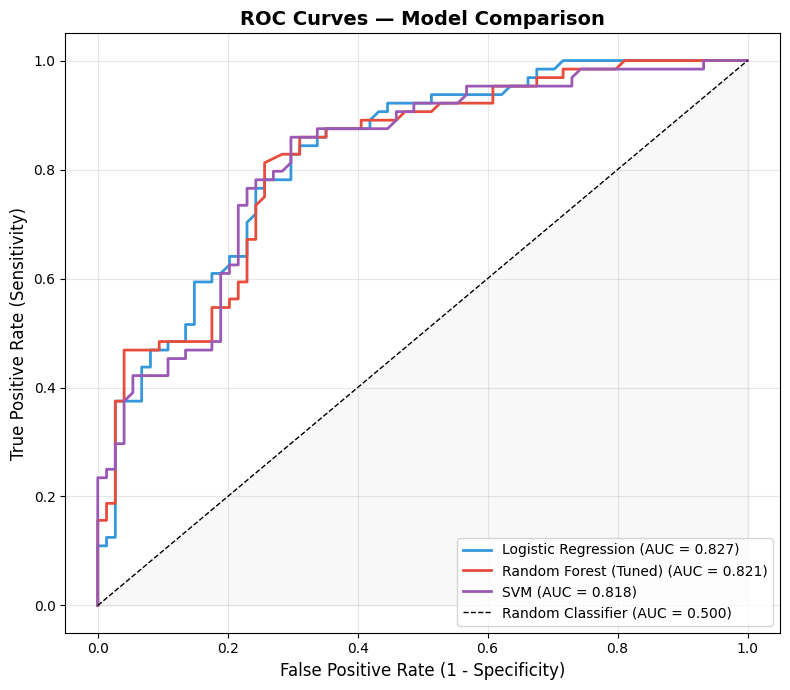

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_models = {
    'Logistic Regression':   (y_prob_lr,       '#3498db'),
    'Random Forest (Tuned)': (y_prob_best_rf,  '#e74c3c'),
    'SVM':                   (y_prob_svm,      '#9b59b6'),
}

for name, (probs, color) in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Feature Importance (Random Forest)

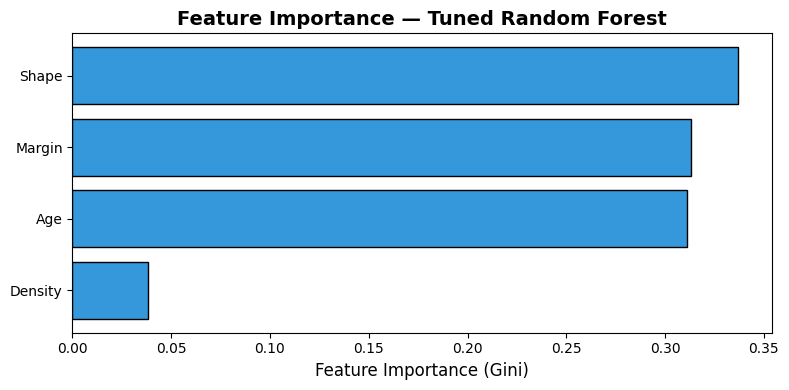

Shape      0.3372
Margin     0.3133
Age        0.3114
Density    0.0382
dtype: float64


In [17]:
feature_importance = pd.Series(best_rf.feature_importances_, index=model_features).sort_values()

plt.figure(figsize=(8, 4))
plt.barh(feature_importance.index, feature_importance.values, color='#3498db', edgecolor='black')
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(feature_importance.sort_values(ascending=False).round(4))

### 5.4 Threshold Tuning — Clinical Decision

Adjusting the classification threshold allows us to trade off between sensitivity (catching cancers) and specificity (avoiding unnecessary biopsies).

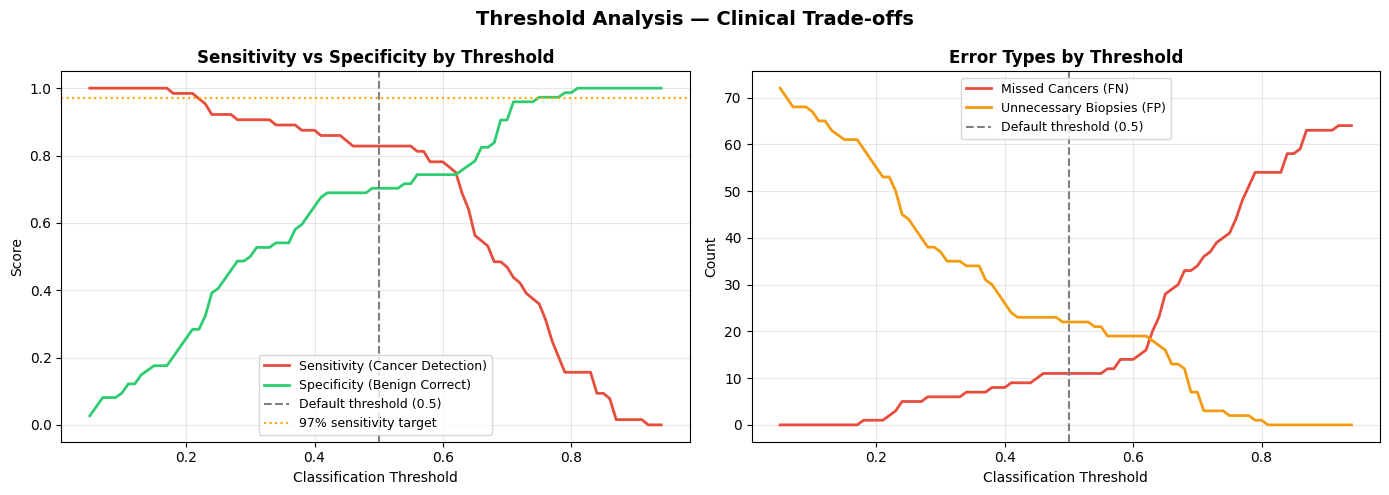

Recommended Clinical Threshold: 0.21
  Sensitivity: 0.9844
  Specificity: 0.2838
  Missed Cancers (FN):       1
  Unnecessary Biopsies (FP): 53


In [18]:
thresholds = np.arange(0.05, 0.95, 0.01)
thresh_results = []

for t in thresholds:
    y_pred_t = (y_prob_best_rf >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    thresh_results.append({
        'Threshold':   round(t, 2),
        'Sensitivity': tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0,
        'Specificity': tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0,
        'FN': fn_t,
        'FP': fp_t
    })

thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['Threshold'], thresh_df['Sensitivity'],
             label='Sensitivity (Cancer Detection)', color=MALIGNANT_COLOR, linewidth=2)
axes[0].plot(thresh_df['Threshold'], thresh_df['Specificity'],
             label='Specificity (Benign Correct)', color=BENIGN_COLOR, linewidth=2)
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[0].axhline(y=0.97, color='orange', linestyle=':', linewidth=1.5, label='97% sensitivity target')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Sensitivity vs Specificity by Threshold', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['Threshold'], thresh_df['FN'],
             label='Missed Cancers (FN)', color=MALIGNANT_COLOR, linewidth=2)
axes[1].plot(thresh_df['Threshold'], thresh_df['FP'],
             label='Unnecessary Biopsies (FP)', color='#f39c12', linewidth=2)
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Types by Threshold', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Analysis — Clinical Trade-offs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

clinical = thresh_df[thresh_df['Sensitivity'] >= 0.97].nlargest(1, 'Specificity')
if not clinical.empty:
    rec = clinical.iloc[0]
    print(f'Recommended Clinical Threshold: {rec["Threshold"]:.2f}')
    print(f'  Sensitivity: {rec["Sensitivity"]:.4f}')
    print(f'  Specificity: {rec["Specificity"]:.4f}')
    print(f'  Missed Cancers (FN):       {int(rec["FN"])}')
    print(f'  Unnecessary Biopsies (FP): {int(rec["FP"])}')

---
## Summary & Business Interpretation

### Answer to the Business Question

> *Can we develop a ML model to assist radiologists in distinguishing malignant from benign breast masses, to reduce unnecessary biopsies while maintaining high cancer detection rates?*

**Yes** — even with a small number of features and real-world missing data, our models achieve strong discriminative performance.

### Key Differences from the Wisconsin Dataset

| Aspect | Wisconsin (Clean) | Mammographic Mass (Messy) |
|---|---|---|
| Features | 30 continuous | 4 ordinal (post BI-RADS drop) |
| Missing values | None | Yes — required imputation |
| Class balance | 63% benign | ~54% benign |
| Data leakage risk | None | BI-RADS must be dropped |
| Expected performance | Higher (~97%) | Lower — fewer, noisier features |

### Clinical Interpretation

- **Sensitivity is the priority metric** — missing a cancer is far more costly than an unnecessary biopsy
- **Margin and shape** are expected to be the most clinically meaningful features
- **Threshold tuning** allows the model to be calibrated to acceptable clinical risk
- **Imputation choices matter** — median imputation assumes missingness is random; in practice, missing density values may be non-random and worth investigating further

### Limitations & Next Steps

- Only 4 features after dropping BI-RADS — inherently limits ceiling performance
- Median imputation is a simplification — KNN imputation could be explored
- External validation on independent data required before any clinical use
- Future work: combine mammographic features with patient demographics or biopsy results